In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d abhinavwalia95/entity-annotated-corpus


Dataset URL: https://www.kaggle.com/datasets/abhinavwalia95/entity-annotated-corpus
License(s): DbCL-1.0
  0% 0.00/26.4M [00:00<?, ?B/s]
100% 26.4M/26.4M [00:00<00:00, 1.58GB/s]


### Data Loading and Exploration

In [ ]:
!unzip /content/entity-annotated-corpus.zip

Archive:  /content/entity-annotated-corpus.zip
  inflating: ner.csv                 
  inflating: ner_dataset.csv         


Identify named entities

In [ ]:
import pandas as pd

df = pd.read_csv("/content/ner_dataset.csv" ,encoding='latin1')
df = df.ffill()
df.head()


,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O


In [ ]:
df["Tag"].unique()

array(['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim',
       'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve',
       'I-eve', 'I-nat'], dtype=object)

# Entities
geo ==> Geographical Entity

gpe ==> Geo-Political Entity

per ==> Person

org ==> Organization

tim ==> Time

art ==> Artifact

nat ==> Natural Phenomenon

eve ==> Event

In [ ]:
print(f"Unique Words: {df['Word'].nunique()}")
print(f"Unique POS Tags: {df['POS'].nunique()}")
print(f"Unique NER Tags: {df['Tag'].nunique()}")


Unique Words: 35177
Unique POS Tags: 42
Unique NER Tags: 17


In [ ]:
def prepare_sentences(df):

  #  To collect data within each sentence
  def make_sentence(group):
      return list(zip(group['Word'], group['POS'], group['Tag']))

  # Collect the rows according to the sentence number

  grouped = df.groupby('Sentence #').apply(make_sentence)

  # Convert values ​​to a list of sentences only (without the sentence name)
  sentences = list(grouped)

  def get_next_sentences():
      for sent_name, sent_data in grouped.items():
            yield sent_name, sent_data

  return grouped, sentences, get_next_sentences()

grouped, sentences, next_sent_gen = prepare_sentences(df)



/tmp/ipython-input-3694908196.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby('Sentence #').apply(make_sentence)


# Mapping & Padding

In [ ]:
words = df["Word"].unique().tolist()
words.append('ENDPAD')
num_words = len(words)
num_words


35178

In [ ]:
tags = df['Tag'].unique().tolist()
num_tags = len(tags)
num_tags

17

In [ ]:
word2idx = dict(zip(words, range(1, len(words) + 1)))
tag2idx = dict(zip(tags, range(len(tags))))
tag2idx

{'O': 0,
 'B-geo': 1,
 'B-gpe': 2,
 'B-per': 3,
 'I-geo': 4,
 'B-org': 5,
 'I-org': 6,
 'B-tim': 7,
 'B-art': 8,
 'I-art': 9,
 'I-per': 10,
 'I-gpe': 11,
 'I-tim': 12,
 'B-nat': 13,
 'B-eve': 14,
 'I-eve': 15,
 'I-nat': 16}

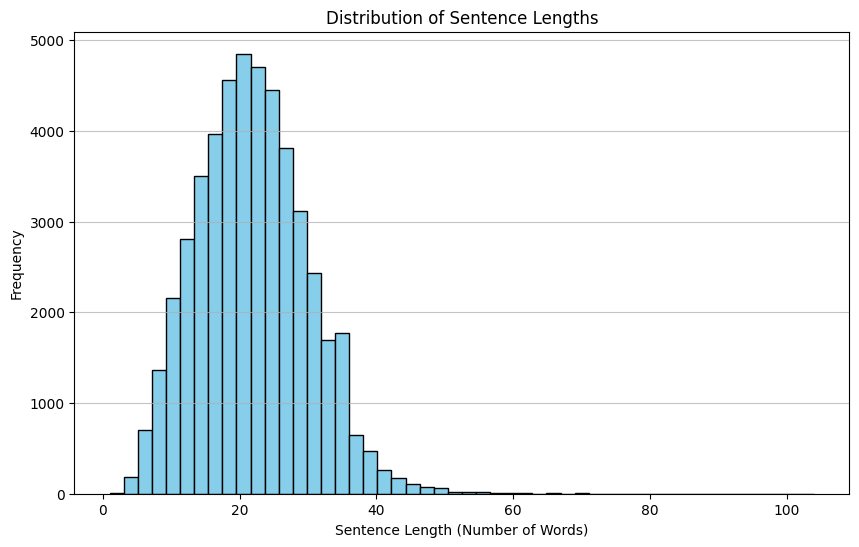

In [ ]:
import matplotlib.pyplot as plt

sentence_lengths = [len(s) for s in sentences]

plt.figure(figsize=(10, 6))
plt.hist(sentence_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Sentence Length (Number of Words)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import tensorflow as tf

X = list(map(lambda s: [word2idx[w[0]] for w in s], sentences))
y = list(map(lambda s: [tag2idx[w[2]] for w in s], sentences))


X = tf.keras.preprocessing.sequence.pad_sequences(
    sequences=X,
    maxlen=50,
    padding='post',
    truncating='post',
    value=word2idx['ENDPAD']
)
y = tf.keras.preprocessing.sequence.pad_sequences(
    sequences=y,
    maxlen=50,
    padding='post',
    truncating='post',
    value=tag2idx['O']
)

print(f"Y:{y}\n\n X:{X}")

Y:[[0 0 0 ... 0 0 0]
 [2 0 0 ... 0 0 0]
 [0 0 7 ... 0 0 0]
 ...
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 5 6 ... 0 0 0]]

 X:[[    1     2     3 ... 35178 35178 35178]
 [  125   126   127 ... 35178 35178 35178]
 [  943   944   364 ... 35178 35178 35178]
 ...
 [ 3184   111    69 ... 35178 35178 35178]
 [ 6503  3207    94 ... 35178 35178 35178]
 [   62   581   820 ... 35178 35178 35178]]


## Spliting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= .2, random_state= 42, shuffle= True)


### BiLSTM Model

In [ ]:
import warnings
warnings.filterwarnings('ignore')

model = tf.keras.models.Sequential([
    #Embedding Layer
    tf.keras.layers.Embedding(input_dim=num_words , output_dim=100, input_length= 50),
    # Bidirectional LSTM Layers
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units= 128, return_sequences= True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units= 64, return_sequences= True)),

    # Fully Connected
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(64, activation='relu')),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.3)),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(num_tags, activation='softmax'))
])

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['accuracy'])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'model.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=100,
                    batch_size= 32,
                    callbacks=[early_stopping, checkpoint])

Epoch 1/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.9896 - loss: 0.0345 - val_accuracy: 0.9852 - val_loss: 0.0534
Epoch 2/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 45s 37ms/step - accuracy: 0.9899 - loss: 0.0328 - val_accuracy: 0.9852 - val_loss: 0.0564
Epoch 3/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.9904 - loss: 0.0311 - val_accuracy: 0.9852 - val_loss: 0.0559
Epoch 4/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 45s 37ms/step - accuracy: 0.9903 - loss: 0.0310 - val_accuracy: 0.9854 - val_loss: 0.0583
Epoch 5/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 45s 37ms/step - accuracy: 0.9908 - loss: 0.0294 - val_accuracy: 0.9851 - val_loss: 0.0580
Epoch 6/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 44s 37ms/step - accuracy: 0.9905 - loss: 0.0311 - val_accuracy: 0.9852 - val_loss: 0.0577


In [ ]:
model.load_weights('model.weights.h5')
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)



300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9851 - loss: 0.0542
Test Loss: 0.05341873690485954
Test Accuracy: 0.9852249026298523


# Predictions

In [ ]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=-1)
i = 5
print("Predicted:", y_pred_classes[i])
print("True:", np.array(y_test[i]))


300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
Predicted: [ 3 10  0  0  0  0  1  0  0  0  0  0  0  0  0  0  3 10  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]
True: [ 3 10  0  0  0  0  1  0  0  0  0  0  0  0  0  0  3 10  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]


In [ ]:
model.save("ner_model.keras")


In [ ]:
loaded_model = tf.keras.models.load_model("ner_model.keras")


In [ ]:

i = 0
sample = X_test[i]

y_pred = loaded_model.predict(np.array([sample]))
y_pred_class = np.argmax(y_pred, axis=-1)[0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
for w, true_t, pred_t in zip(sample, y_test[i], y_pred_class):
    if w != 0:
        print(f"{idx2word[w]:15}  true: {idx2tag[true_t]:8}  pred: {idx2tag[pred_t]}")


The              true: O         pred: O
report           true: O         pred: O
calls            true: O         pred: O
on               true: O         pred: O
President        true: B-per     pred: B-per
Bush             true: I-per     pred: I-per
and              true: O         pred: O
Congress         true: B-org     pred: B-org
to               true: O         pred: O
urge             true: O         pred: O
Chinese          true: B-gpe     pred: B-gpe
officials        true: O         pred: O
not              true: O         pred: O
to               true: O         pred: O
use              true: O         pred: O
the              true: O         pred: O
global           true: O         pred: O
war              true: O         pred: O
against          true: O         pred: O
terrorism        true: O         pred: O
as               true: O         pred: O
a                true: O         pred: O
pretext          true: O         pred: O
to               true: O         pred: O
